In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_aq = pd.read_csv('AirQuality.csv', sep=';', decimal=',')

In [3]:
df_aq.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [4]:
print("Null Values: ", df_aq.isnull().sum())
df_aq.shape

Null Values:  Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S5(O3)       114
T                 114
RH                114
AH                114
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64


(9471, 17)

In [5]:
df_aq.drop(columns=['Unnamed: 15','Unnamed: 16'],inplace=True)

In [6]:
df_aq.dropna(inplace=True)
df_aq.shape

(9357, 15)

In [7]:
print("Null Values: ", df_aq.isnull().sum())

Null Values:  Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [8]:
df_aq.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


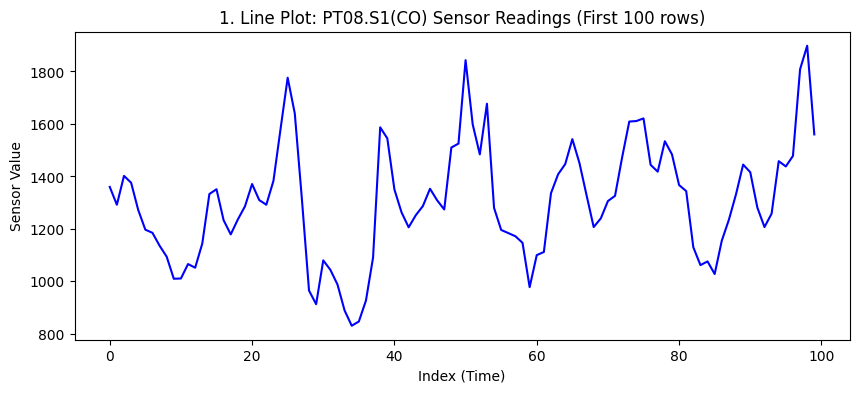

In [9]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_aq.head(100), x=df_aq.head(100).index, y='PT08.S1(CO)', color='blue')
plt.title('1. Line Plot: PT08.S1(CO) Sensor Readings (First 100 rows)')
plt.xlabel('Index (Time)')
plt.ylabel('Sensor Value')
plt.show()

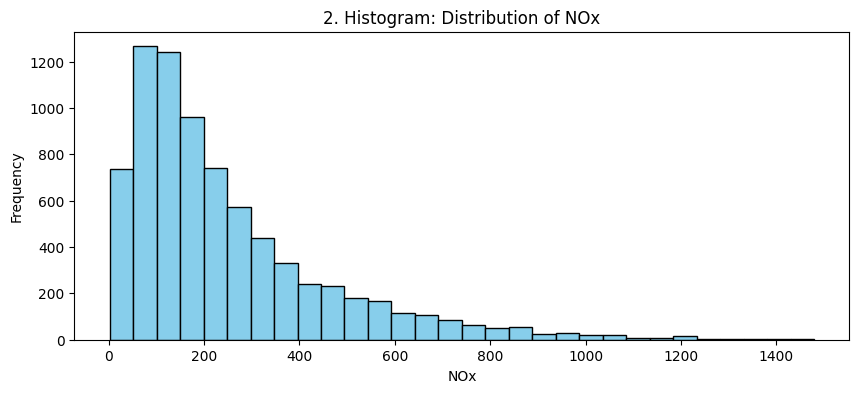

In [10]:
plt.figure(figsize=(10, 4))
valid_nox = df_aq['NOx(GT)'].replace(-200, None).dropna()

plt.hist(valid_nox, bins=30, color='skyblue', edgecolor='black')
plt.title('2. Histogram: Distribution of NOx')
plt.xlabel('NOx')
plt.ylabel('Frequency')
plt.show()

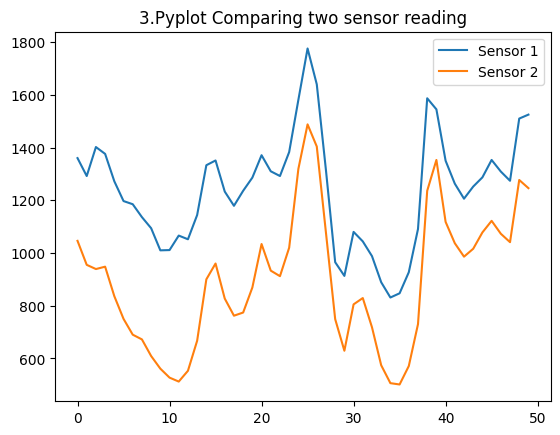

In [12]:
y1 = df_aq['PT08.S1(CO)'].head(50)
y2 = df_aq['PT08.S2(NMHC)'].head(50)

plt.plot(y1, label='Sensor 1')
plt.plot(y2, label='Sensor 2')
plt.title('3.Pyplot Comparing two sensor reading')
plt.legend()
plt.show()

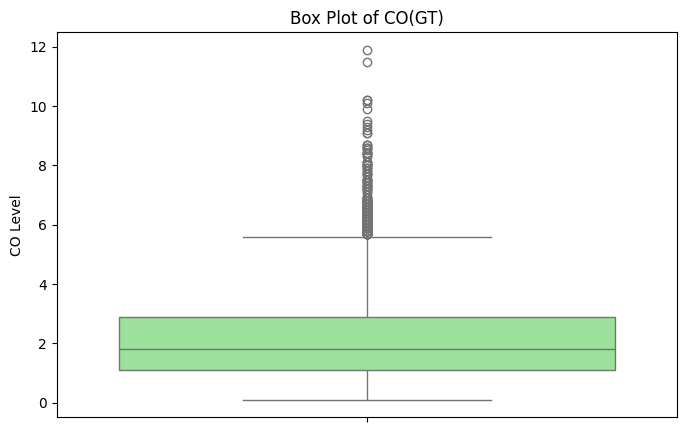

In [15]:
valid_co = df_aq['CO(GT)'].replace(-200, None).dropna()
plt.figure(figsize=(8,5))
sns.boxplot(data=valid_co, color='lightgreen')
plt.title('Box Plot of CO(GT)')
plt.ylabel('CO Level')
plt.show()

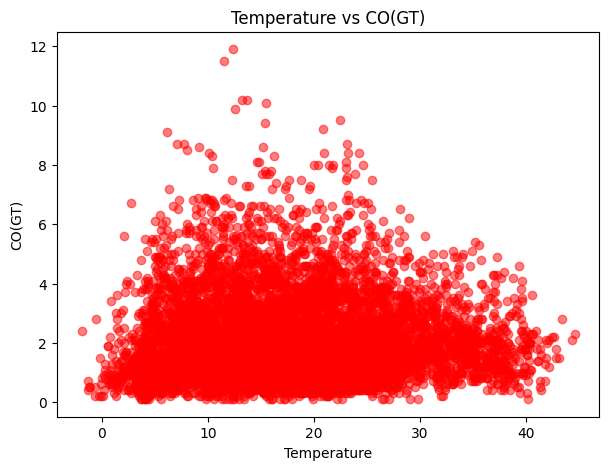

In [17]:
import numpy as np

df_aq.replace(-200, np.nan, inplace=True)

plt.figure(figsize=(7,5))
plt.scatter(df_aq['T'], df_aq['CO(GT)'], alpha=0.5, color='red')
plt.title("Temperature vs CO(GT)")
plt.xlabel("Temperature")
plt.ylabel("CO(GT)")
plt.show()

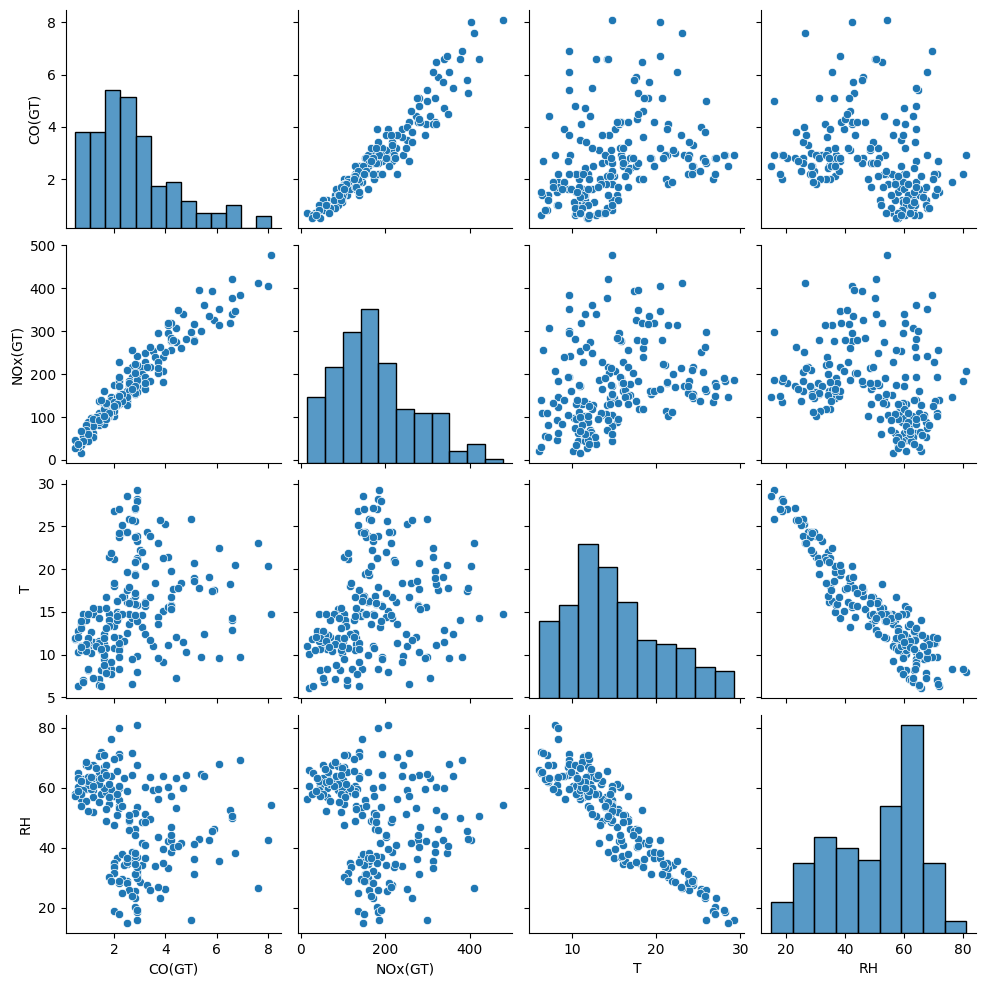

In [21]:
sample_data = df_aq[['CO(GT)', 'NOx(GT)', 'T', 'RH']].head(200)

sns.pairplot(sample_data)

plt.show()

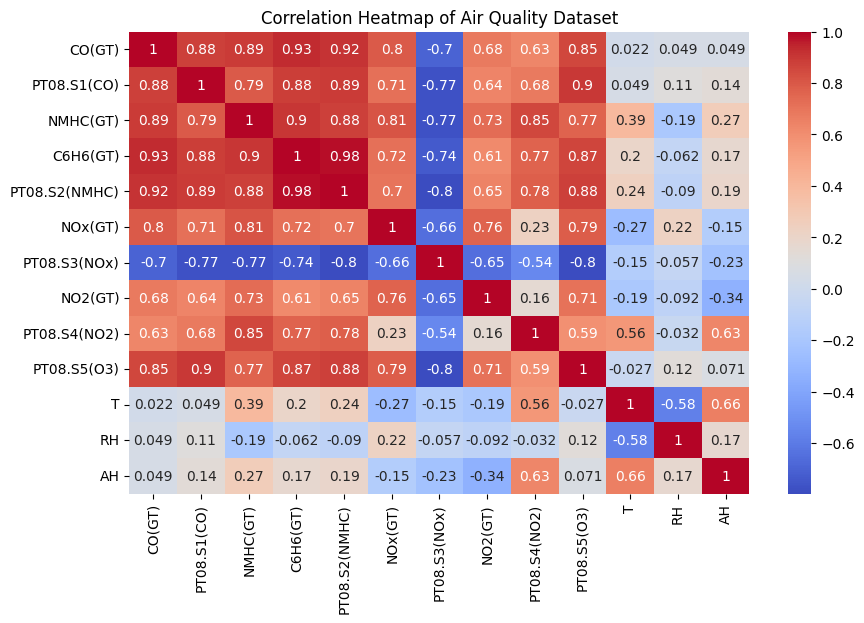

In [19]:
plt.figure(figsize=(10,6))
corr_data = df_aq.select_dtypes(include=['float64','int64']).corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Air Quality Dataset")
plt.show()

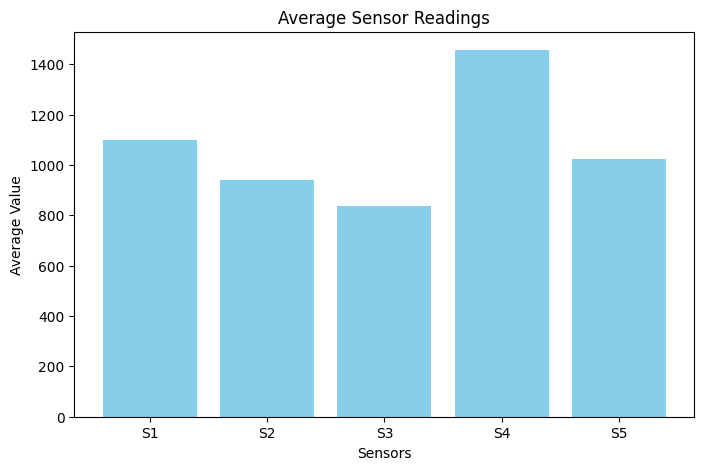

In [22]:
sensor_avg = [
    df_aq['PT08.S1(CO)'].mean(),
    df_aq['PT08.S2(NMHC)'].mean(),
    df_aq['PT08.S3(NOx)'].mean(),
    df_aq['PT08.S4(NO2)'].mean(),
    df_aq['PT08.S5(O3)'].mean()
]

sensor_names = ['S1', 'S2', 'S3', 'S4', 'S5']

plt.figure(figsize=(8,5))

plt.bar(sensor_names, sensor_avg, color='skyblue')

plt.title("Average Sensor Readings")

plt.xlabel("Sensors")

plt.ylabel("Average Value")

plt.show()

In [11]:
df_ff = pd.read_csv('forestfires.csv')

In [12]:
df_ff.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [13]:
df_ff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


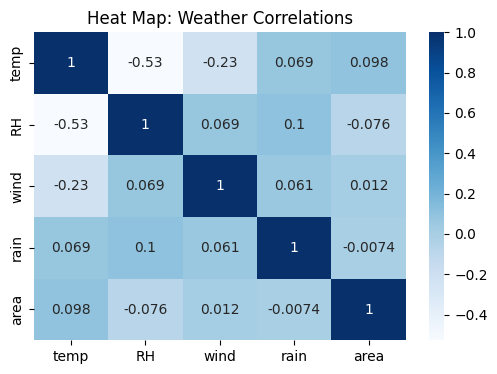

In [14]:
weather_data = df_ff[['temp', 'RH', 'wind', 'rain', 'area']]

plt.figure(figsize=(6, 4))
sns.heatmap(weather_data.corr(), annot=True, cmap='Blues')
plt.title('Heat Map: Weather Correlations')
plt.show()

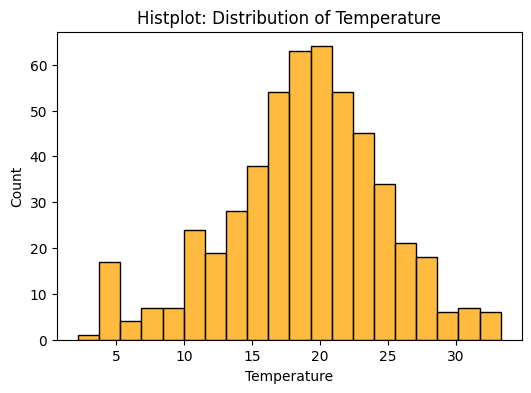

In [15]:
plt.figure(figsize=(6, 4))
sns.histplot(df_ff['temp'], color='orange', bins=20)
plt.title('Histplot: Distribution of Temperature')
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.show()

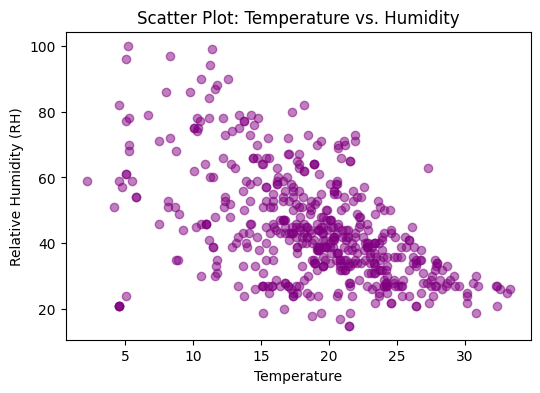

In [16]:
plt.figure(figsize=(6, 4))
plt.scatter(df_ff['temp'], df_ff['RH'], alpha=0.5, color='purple')
plt.title('Scatter Plot: Temperature vs. Humidity')
plt.xlabel('Temperature')
plt.ylabel('Relative Humidity (RH)')
plt.show()

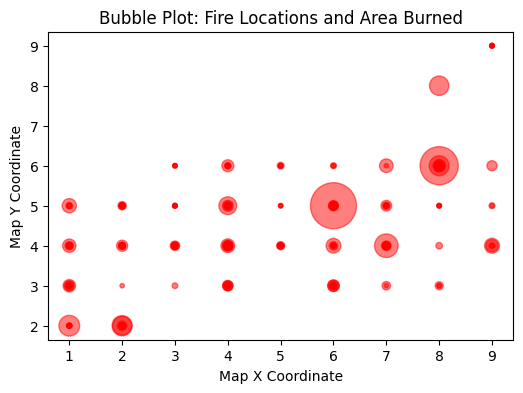

In [17]:
plt.figure(figsize=(6, 4))

plt.scatter(x=df_ff['X'], y=df_ff['Y'], s=df_ff['area'] + 10, alpha=0.5, color='red')

plt.title('Bubble Plot: Fire Locations and Area Burned')
plt.xlabel('Map X Coordinate')
plt.ylabel('Map Y Coordinate')
plt.show()

In [24]:
df_h1 = pd.read_csv('heart_disease_uci.csv')

In [25]:
df_h1.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [26]:
df_h1.dtypes

id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

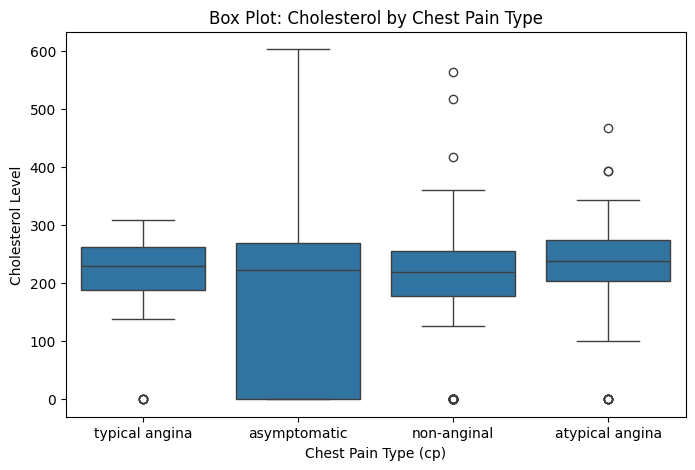

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_h1, x='cp', y='chol')

plt.title('Box Plot: Cholesterol by Chest Pain Type')
plt.xlabel('Chest Pain Type (cp)')
plt.ylabel('Cholesterol Level')
plt.show()

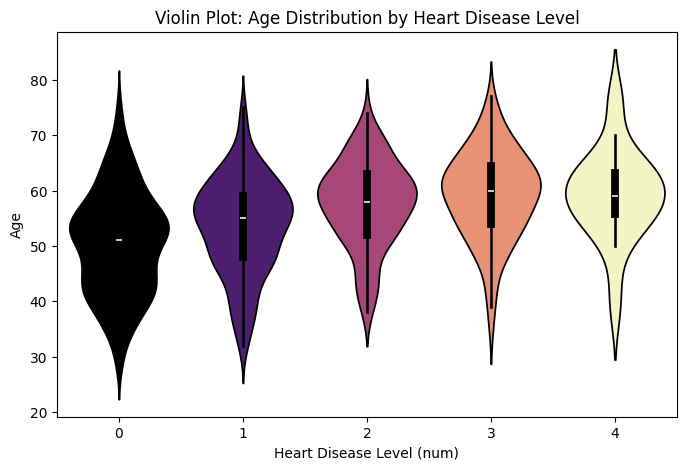

In [28]:
plt.figure(figsize=(8, 5))

# Creating a violin plot (Updated to avoid the seaborn FutureWarning)
sns.violinplot(data=df_h1, x='num', y='age', hue='num', palette='magma', legend=False)

plt.title('Violin Plot: Age Distribution by Heart Disease Level')
plt.xlabel('Heart Disease Level (num)')
plt.ylabel('Age')
plt.show()

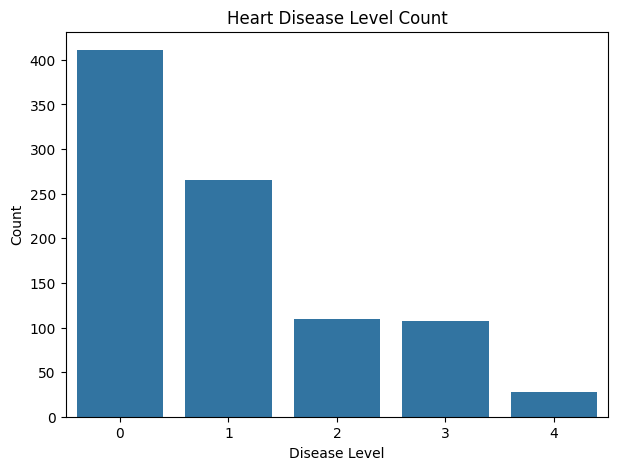

In [30]:
plt.figure(figsize=(7,5))
sns.countplot(x='num', data=df_h1)
plt.title("Heart Disease Level Count")
plt.xlabel("Disease Level")
plt.ylabel("Count")
plt.show()

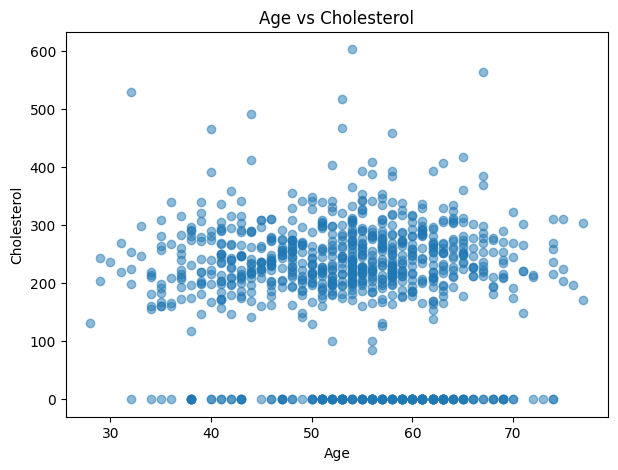

In [31]:
plt.figure(figsize=(7,5))
plt.scatter(df_h1['age'], df_h1['chol'], alpha=0.5)
plt.title("Age vs Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.show()

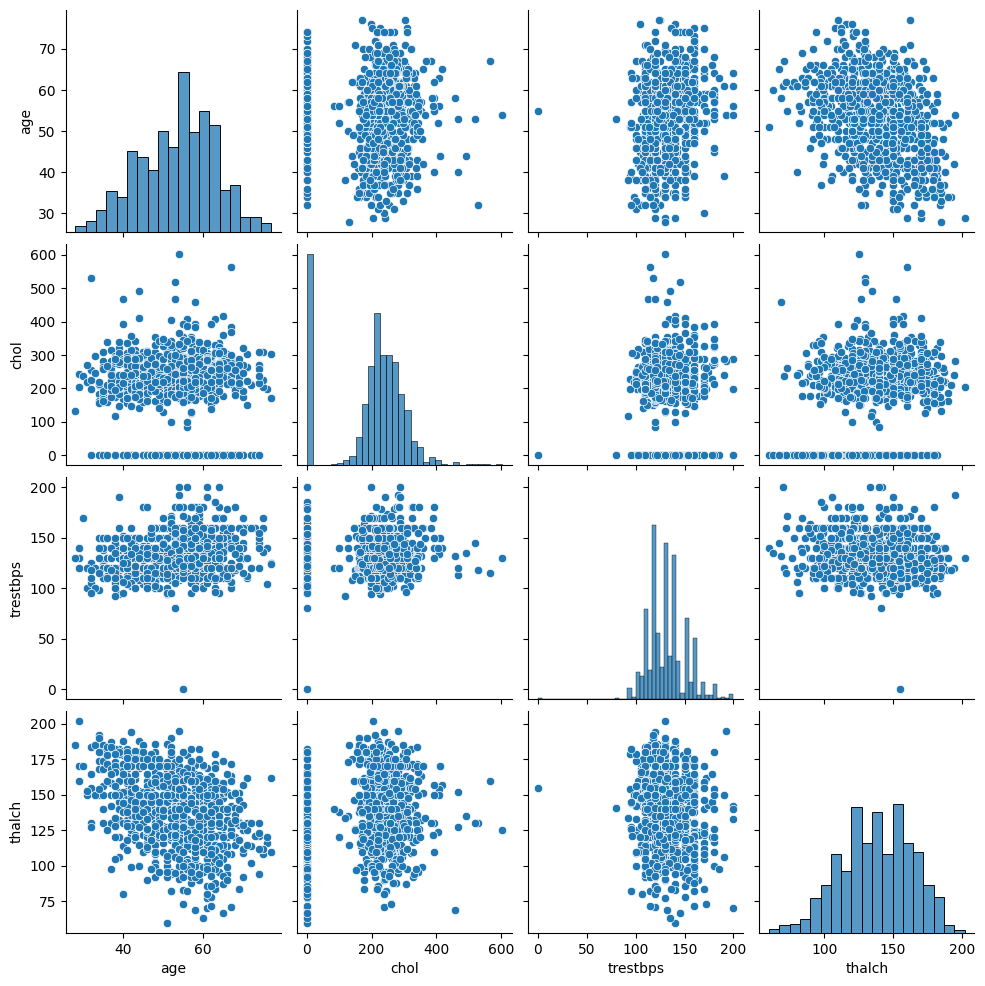

In [32]:
cols = ['age', 'chol', 'trestbps', 'thalch']

sns.pairplot(df_h1[cols])

plt.show()

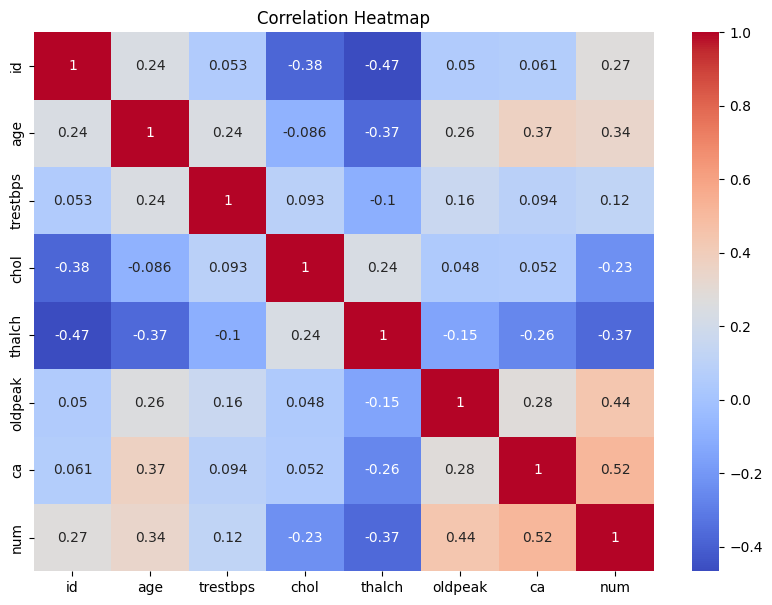

In [35]:
numeric_data = df_h1.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,7))

sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()